In [31]:
import dendropy
import pandas as pd

from dendropy import Taxon
from scipy.special import logit, expit
from aux_fns import *

In [22]:
AD = pd.read_csv("../process_dlp_data/AD_true.csv", index_col=0)
DP = pd.read_csv("../process_dlp_data/DP_true.csv", index_col=0)

In [17]:
edges = pd.read_csv("../process_dlp_data/edges.csv", index_col=0)
edges.cell_id = edges.cell_id.astype(str)
edges.ancestor = edges.ancestor.astype(str)
leaves = set(edges.cell_id.astype(str).tolist()) - set(edges.ancestor.tolist())

N = len(leaves)

In [3]:
if "root" not in edges["cell_id"].values:
    edges = pd.concat([pd.DataFrame({"cell_id": ["root"], "ancestor": [None], "birth_time": [0]}), edges])

In [4]:
# crea un dizionario per tenere i nodi
taxa = dendropy.TaxonNamespace(leaves)
nodes = {"root": dendropy.Node(label="root")}
tree = dendropy.Tree(seed_node=nodes["root"], taxon_namespace=taxa)

# funzione helper per ottenere o creare nodi
def get_node(label):
    if label not in nodes:
        nodes[label] = dendropy.Node(label=label)
    if label in leaves:
        nodes[label].taxon = taxa.get_taxon(label)
    return nodes[label]

In [5]:
# costruzione ricorsiva: collega ogni nodo al suo antenato
for _, row in edges.iterrows():
    if row["ancestor"] is None:
        continue
    parent = get_node(row["ancestor"])
    child = get_node(row["cell_id"])
    parent.add_child(child)
    child.edge.length = float(row["weight"])

# attacca tutti i nodi al seme
tree.seed_node = nodes["root"]

In [6]:
assignments, linkage_matrix = assign_clones_from_tree(tree, K=2)  # dict: {cell_id:clone_id, ...}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

In [7]:
unique_groups = set(clone_ids)
color_list = ["#5F9EA0","#FF4500","#DAA520","#7B68EE"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]

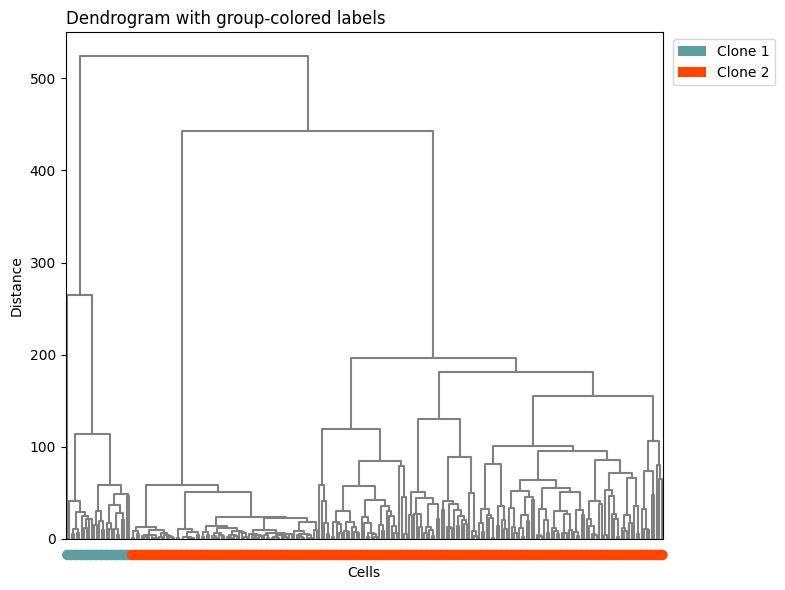

In [8]:
plot_dendogram(linkage_matrix, cell_ids, clone_ids, color_map)

In [9]:
edges = tree_to_edge_list(tree)

In [10]:
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=.05, sigma_squared=1.0)
# pd.DataFrame(kernel).to_csv(save_path + "kernel.csv", index=False)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

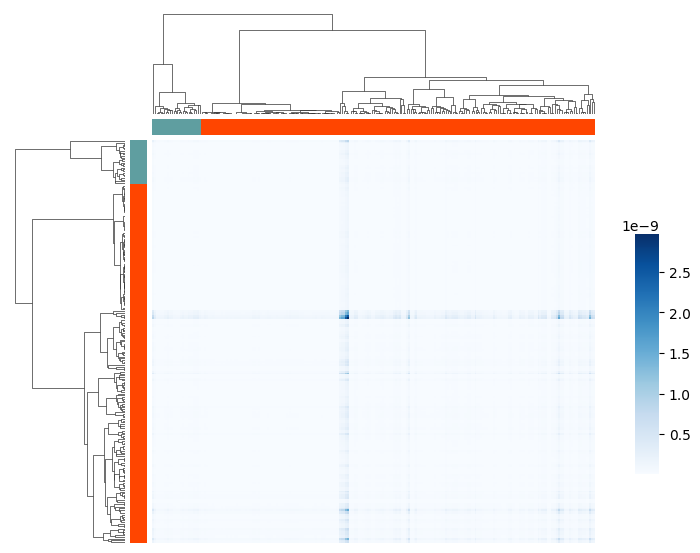

In [ ]:
plot_heatmap(kernel, col_colors=label_colors, row_colors=label_colors,
             linkage_matrix_col=linkage_matrix, linkage_matrix_row=linkage_matrix)

In [50]:
theta_t = (AD/DP).fillna(0)
theta_t[theta_t==0] = 1e-15
theta_t[theta_t==1] = 1. - 1e-15
gamma_t = mu_t = logit(theta_t)

In [52]:
data_true = pd.concat([array_to_df(theta_t, "VAF", cell_ids), \
                       array_to_df(AD, "AD", cell_ids)["AD"], \
                       array_to_df(DP, "DP", cell_ids)["DP"], \
                       array_to_df(gamma_t, "gamma", cell_ids)["gamma"]], \
                       axis=1, join="inner")
data_true["clone_ids"] = [str(assignments[i]) for i in data_true["cell_ids"]]
data_true.head()

,mutation_ids,cell_ids,VAF,AD,DP,gamma,clone_ids
0,chr1:13214838:A:C,22567,1.0,1,1,34.539576,2
1,chr1:17242907:C:A,22567,1.0,1,1,34.539576,2
2,chr1:22792554:T:C,22567,1.0,1,1,34.539576,2
3,chr1:30652995:A:C,22567,1.0,1,1,34.539576,2
4,chr1:32628568:G:A,22567,1.0,1,1,34.539576,2
